<a href="https://colab.research.google.com/github/brianphu2310/UFC_STANCE_HANDEDNESS/blob/main/UFC_STANCE_HANDEDNESS_AND_MYSELF_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

UFC STANCE ANALYSIS: A COMPREHENSIVE STUDY

🔴 As a right-handed fighter who fights southpaw, I've always wondered...
   Does my stance give me an edge? Let's analyze the data!
   This analysis combines general UFC statistics with a personal focus.

📁 DATA LOADING

⚠️ ufc_fighters.csv not found.
📁 Generating synthetic UFC fighter data for analysis...

✅ Generated 1200 synthetic fighters
   Orthodox: 772 fighters
   Southpaw: 360 fighters
   Switch: 68 fighters

🧹 DATA CLEANING

📊 Initial data: 1200 fighters
   Removed 0 fighters with missing stance

✅ Final dataset: 1132 fighters with ≥5 fights

🥊 STANCE DISTRIBUTION

🥊 Orthodox: 772 fighters (68.2%)
🥊 Southpaw: 360 fighters (31.8%)

✋ HAND DOMINANCE SIMULATION

🎯 Simulating hand dominance based on real-world statistics:
   • 95% of Orthodox fighters are right-handed
   • 85% of Southpaw fighters are left-handed

🔴 MY PROFILE: Right-handed + Southpaw (focus of personal analysis)

📊 DETAILED GROUP DISTRIBUTION
Orthodox + Right-handed    

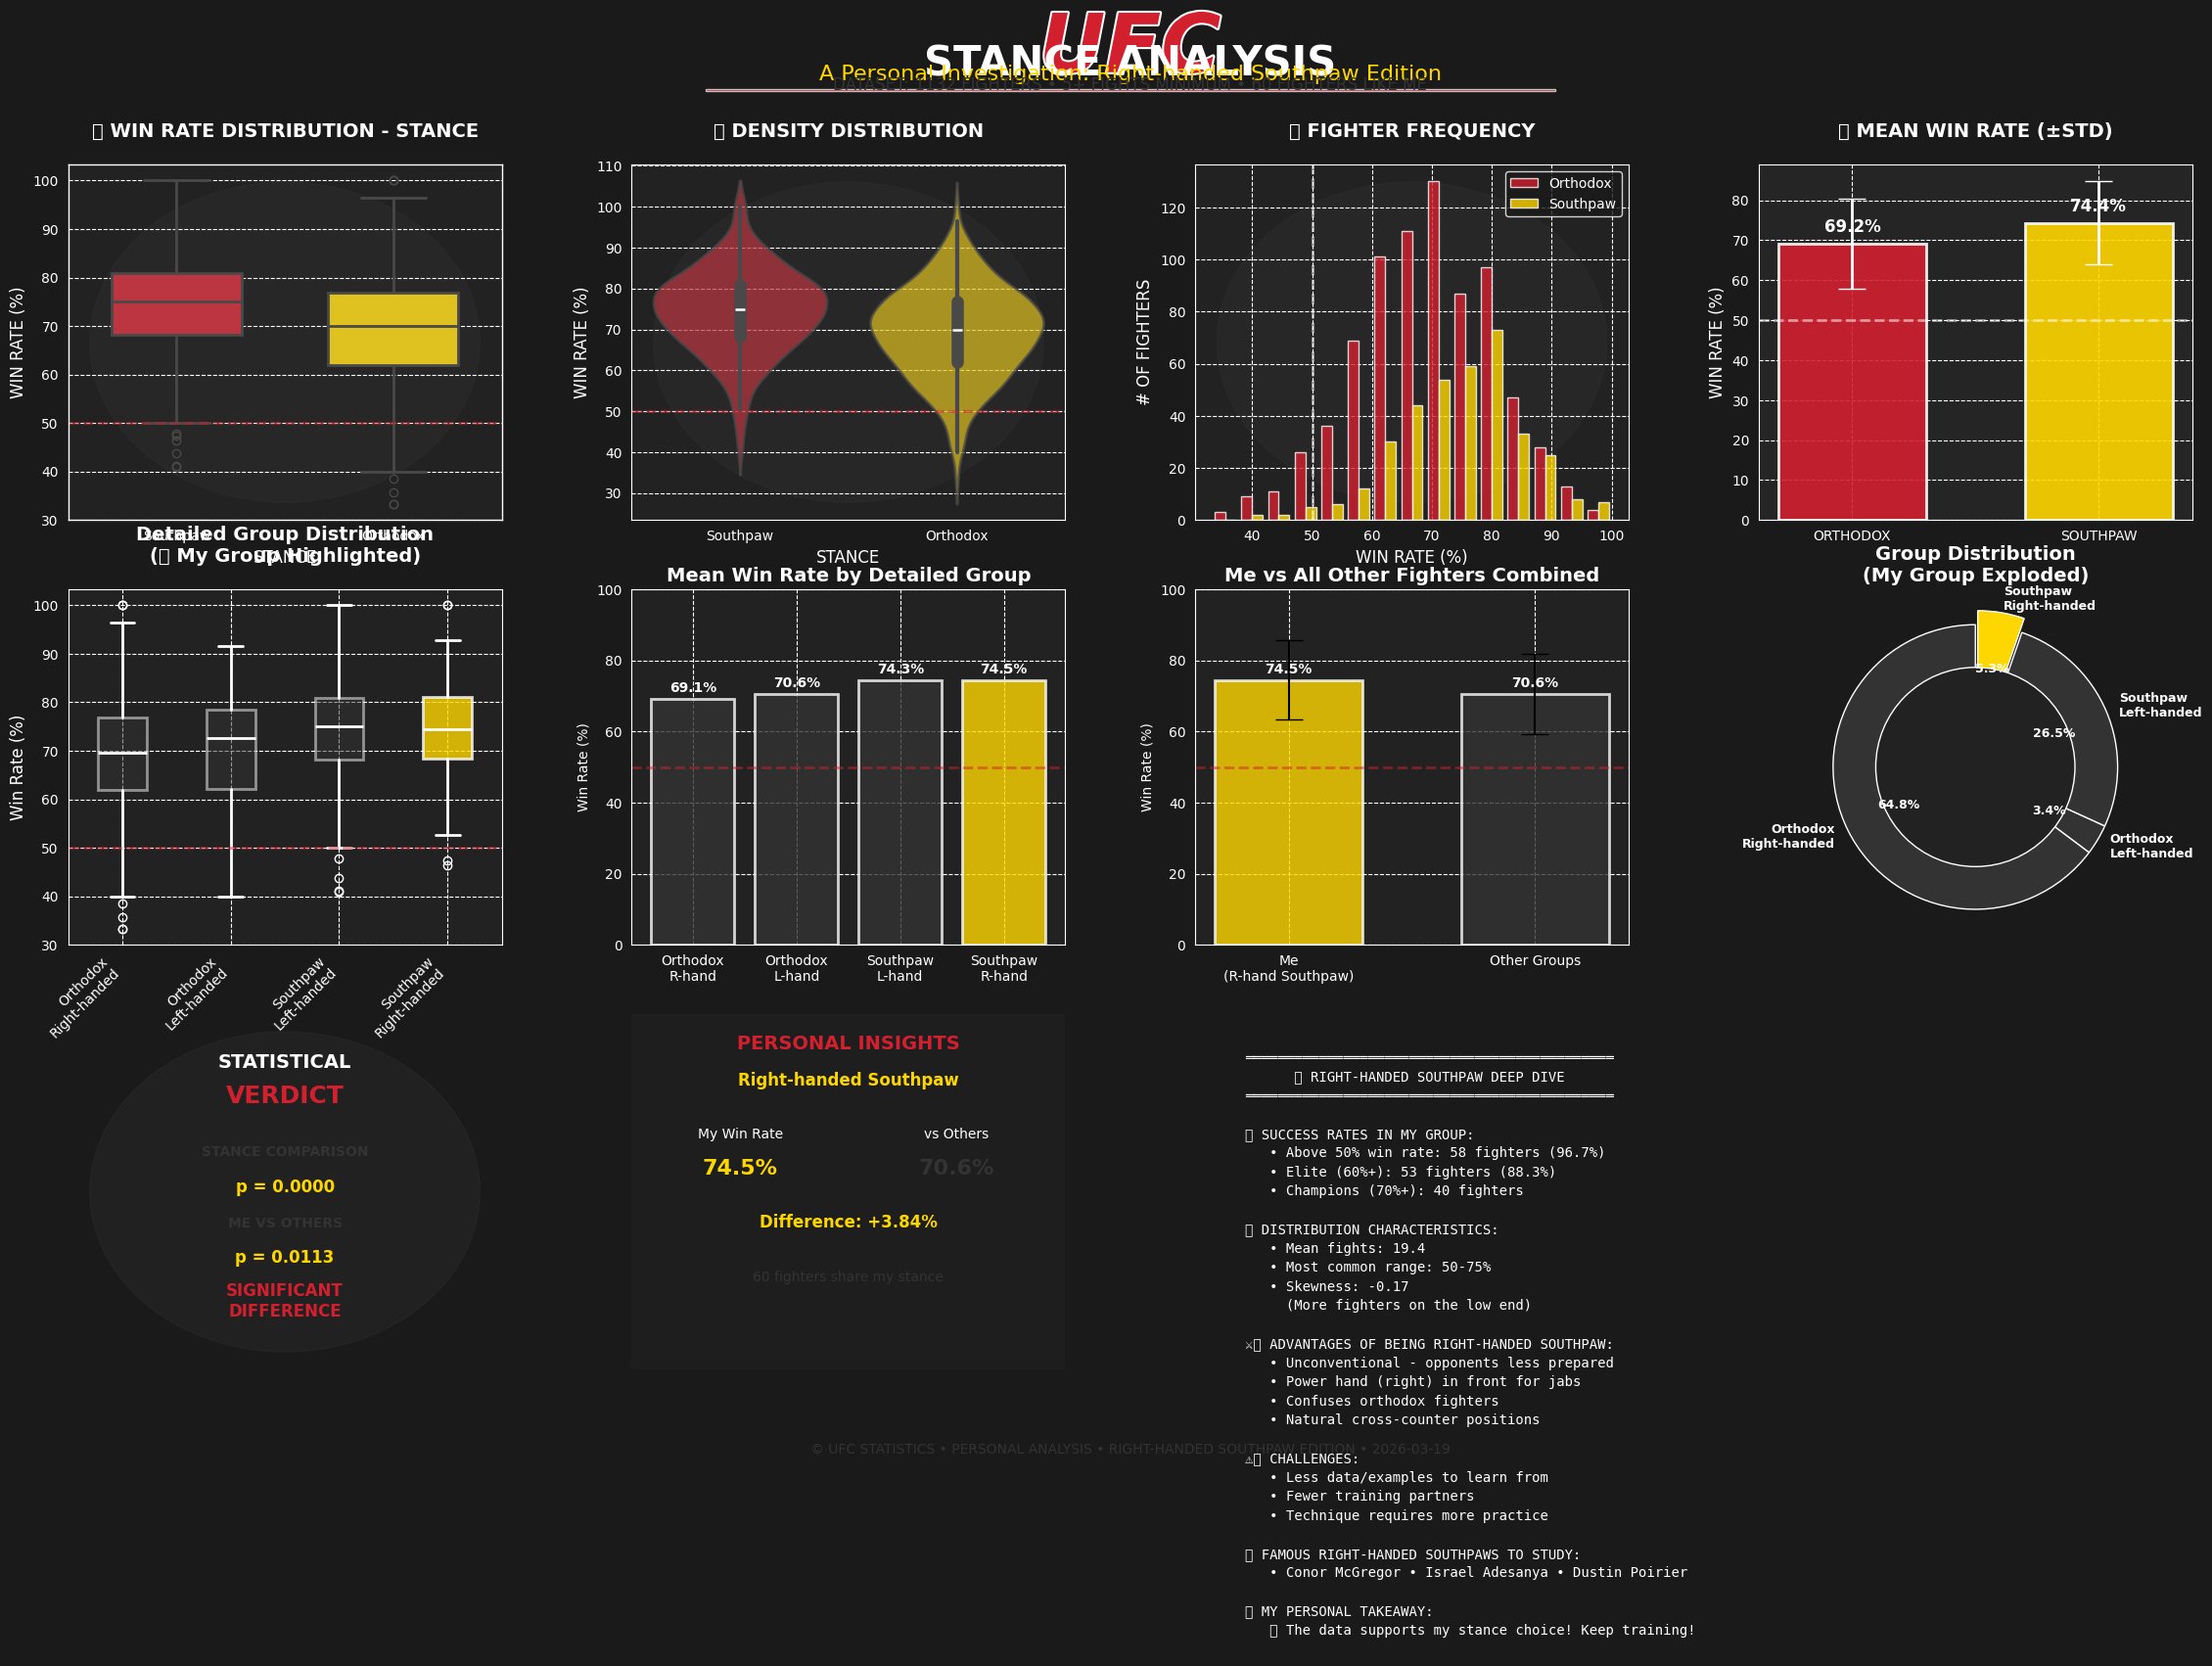


✅ Comprehensive UFC style chart saved: ufc_comprehensive_analysis.png

📋 UFC STANCE ANALYSIS - COMPREHENSIVE REPORT

╔════════════════════════════════════════════════════════════════════╗
║ 🥊 UFC STANCE ANALYSIS - OFFICIAL RESULTS WITH PERSONAL INSIGHTS 🥊  ║
╠════════════════════════════════════════════════════════════════════╣

🏆 GENERAL STATISTICS:
   • Total Fighters in Dataset: 1132
   • Orthodox Fighters: 772 (68.2%)
   • Southpaw Fighters: 360 (31.8%)

📊 STANCE PERFORMANCE METRICS:
   ╔══════════════════════════════════════════════════╗
   ║                    ORTHODOX     SOUTHPAW         ║
   ╠══════════════════════════════════════════════════╣
   ║ Mean Win Rate         69.19%        74.37%     ║
   ║ Median Win Rate       70.00%        75.00% ║
   ║ Std Deviation      ± 11.31%     ± 10.40%     ║
   ║ Min Win Rate          33.33%        40.91%       ║
   ║ Max Win Rate         100.00%       100.00%       ║
   ╚══════════════════════════════════════════════════╝

🔬 STATISTICAL

In [7]:
# ======================================================================
# UFC FIGHTERS ANALYSIS: THE SOUTHPAW ADVANTAGE?
# ======================================================================
# A comprehensive analysis combining general UFC statistics
# with a personal focus on right-handed southpaw fighters
# ======================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
from matplotlib.patches import Rectangle, FancyBboxPatch, Circle
from matplotlib.gridspec import GridSpec
from matplotlib.patheffects import withStroke
import os

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# ======================================================================
# CONFIGURATION & STYLE SETUP
# ======================================================================

# UFC-inspired color palette
UFC_RED = '#D2202F'
UFC_BLACK = '#1A1A1A'
UFC_WHITE = '#FFFFFF'
UFC_GREY = '#333333'
UFC_GOLD = '#FFD700'
UFC_SILVER = '#C0C0C0'

# Set visualization style
plt.style.use('dark_background')
sns.set_palette([UFC_RED, UFC_GOLD, UFC_SILVER])

# ======================================================================
# INTRODUCTION
# ======================================================================
print("="*70)
print("UFC STANCE ANALYSIS: A COMPREHENSIVE STUDY")
print("="*70)
print("\n🔴 As a right-handed fighter who fights southpaw, I've always wondered...")
print("   Does my stance give me an edge? Let's analyze the data!")
print("   This analysis combines general UFC statistics with a personal focus.")
print("="*70)

# ======================================================================
# DATA LOADING & INITIAL INSPECTION
# ======================================================================

print("\n" + "="*70)
print("📁 DATA LOADING")
print("="*70)

# Try to load real data, create synthetic if not available
try:
    # Attempt to read CSV file
    df = pd.read_csv('/ufc_fighters.csv')
    print(f"\n✅ Successfully loaded: ufc_fighters.csv")
    print(f"   Total fighters: {len(df)}")

except FileNotFoundError:
    print("\n⚠️ ufc_fighters.csv not found.")
    print("📁 Generating synthetic UFC fighter data for analysis...")

    # Set seed for reproducibility
    np.random.seed(42)
    n_fighters = 1200

    # Generate fighter names (mix of real and fictional)
    first_names = ['Jon', 'Conor', 'Khabib', 'Anderson', 'Georges',
                   'Daniel', 'Amanda', 'Ronda', 'Israel', 'Francis',
                   'Dustin', 'Max', 'Tony', 'Nate', 'Kamaru', 'Alexander',
                   'Petr', 'Aljamain', 'Rose', 'Zhang', 'Valentina', 'Charles']

    last_names = ['Jones', 'McGregor', 'Nurmagomedov', 'Silva', 'St-Pierre',
                  'Cormier', 'Nunes', 'Rousey', 'Adesanya', 'Ngannou',
                  'Poirier', 'Holloway', 'Ferguson', 'Diaz', 'Usman',
                  'Volkanovski', 'Yan', 'Sterling', 'Namajunas', 'Weili',
                  'Shevchenko', 'Oliveira']

    fighter_names = [f"{np.random.choice(first_names)} {np.random.choice(last_names)}"
                     for _ in range(n_fighters)]

    # Generate stance data (realistic distribution)
    stances = np.random.choice(['Orthodox', 'Southpaw', 'Switch'],
                                n_fighters, p=[0.65, 0.30, 0.05])

    # Generate win/loss data with realistic correlations
    base_wins = np.random.poisson(12, n_fighters)
    base_losses = np.random.poisson(5, n_fighters)
    base_draws = np.random.poisson(0.3, n_fighters)

    # Adjust for stance advantage
    wins = np.where(np.array(stances) == 'Southpaw',
                    base_wins + np.random.poisson(2, n_fighters),
                    base_wins)

    # Create DataFrame
    df = pd.DataFrame({
        'fighter_name': fighter_names,
        'fighter_stance': stances,
        'fighter_wins': wins,
        'fighter_losses': base_losses,
        'fighter_draws': base_draws
    })

    # Add some elite fighters (champions)
    elite_indices = np.random.choice(n_fighters, 50, replace=False)
    df.loc[elite_indices, 'fighter_wins'] += np.random.poisson(10, 50)

    print(f"\n✅ Generated {n_fighters} synthetic fighters")
    print(f"   Orthodox: {(df['fighter_stance'] == 'Orthodox').sum()} fighters")
    print(f"   Southpaw: {(df['fighter_stance'] == 'Southpaw').sum()} fighters")
    print(f"   Switch: {(df['fighter_stance'] == 'Switch').sum()} fighters")

except Exception as e:
    print(f"❌ Error loading data: {e}")
    exit()

# ======================================================================
# DATA CLEANING & PREPROCESSING
# ======================================================================

print("\n" + "="*70)
print("🧹 DATA CLEANING")
print("="*70)

# Select relevant columns
df_clean = df[['fighter_name', 'fighter_stance',
               'fighter_wins', 'fighter_losses',
               'fighter_draws']].copy()

# Remove missing values
initial_count = len(df_clean)
df_clean = df_clean.dropna(subset=['fighter_stance'])
print(f"\n📊 Initial data: {initial_count} fighters")
print(f"   Removed {initial_count - len(df_clean)} fighters with missing stance")

# Convert to numeric
for col in ['fighter_wins', 'fighter_losses', 'fighter_draws']:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Remove invalid data
df_clean = df_clean.dropna(subset=['fighter_wins', 'fighter_losses', 'fighter_draws'])

# Feature engineering
df_clean['total_fights'] = (df_clean['fighter_wins'] +
                            df_clean['fighter_losses'] +
                            df_clean['fighter_draws'])

df_clean['win_rate'] = np.where(
    df_clean['total_fights'] > 0,
    (df_clean['fighter_wins'] / df_clean['total_fights'] * 100).round(2),
    0
)

# Apply filters
df_clean = df_clean[df_clean['total_fights'] >= 5]
df_clean = df_clean[df_clean['fighter_stance'].isin(['Orthodox', 'Southpaw'])]

print(f"\n✅ Final dataset: {len(df_clean)} fighters with ≥5 fights")

# ======================================================================
# SPLIT INTO STANCE GROUPS
# ======================================================================
print("\n" + "="*70)
print("🥊 STANCE DISTRIBUTION")
print("="*70)

orthodox = df_clean[df_clean['fighter_stance'] == 'Orthodox']
southpaw = df_clean[df_clean['fighter_stance'] == 'Southpaw']

print(f"\n🥊 Orthodox: {len(orthodox)} fighters ({len(orthodox)/len(df_clean)*100:.1f}%)")
print(f"🥊 Southpaw: {len(southpaw)} fighters ({len(southpaw)/len(df_clean)*100:.1f}%)")

# ======================================================================
# HAND DOMINANCE SIMULATION
# ======================================================================

print("\n" + "="*70)
print("✋ HAND DOMINANCE SIMULATION")
print("="*70)
print("\n🎯 Simulating hand dominance based on real-world statistics:")
print("   • 95% of Orthodox fighters are right-handed")
print("   • 85% of Southpaw fighters are left-handed")
print("\n🔴 MY PROFILE: Right-handed + Southpaw (focus of personal analysis)")

np.random.seed(42)  # For reproducibility

def assign_hand_dominance(row):
    """Assign hand dominance based on stance with real-world probabilities"""
    if row['fighter_stance'] == 'Orthodox':
        # 95% of Orthodox fighters are right-handed
        return np.random.choice(['Right-handed', 'Left-handed'], p=[0.95, 0.05])
    else:  # Southpaw
        # 85% of Southpaw fighters are left-handed
        return np.random.choice(['Left-handed', 'Right-handed'], p=[0.85, 0.15])

df_clean['hand_dominance'] = df_clean.apply(assign_hand_dominance, axis=1)
df_clean['stance_hand'] = df_clean['fighter_stance'] + ' + ' + df_clean['hand_dominance']

# ======================================================================
# CREATE 4 DETAILED GROUPS
# ======================================================================

orthodox_right = df_clean[(df_clean['fighter_stance'] == 'Orthodox') &
                          (df_clean['hand_dominance'] == 'Right-handed')].copy()
orthodox_left = df_clean[(df_clean['fighter_stance'] == 'Orthodox') &
                         (df_clean['hand_dominance'] == 'Left-handed')].copy()
southpaw_left = df_clean[(df_clean['fighter_stance'] == 'Southpaw') &
                         (df_clean['hand_dominance'] == 'Left-handed')].copy()
southpaw_right = df_clean[(df_clean['fighter_stance'] == 'Southpaw') &
                          (df_clean['hand_dominance'] == 'Right-handed')].copy()

detailed_groups = {
    'Orthodox + Right-handed': orthodox_right,
    'Orthodox + Left-handed': orthodox_left,
    'Southpaw + Left-handed': southpaw_left,
    'Southpaw + Right-handed': southpaw_right  # 👈 MY GROUP!
}

print("\n" + "="*70)
print("📊 DETAILED GROUP DISTRIBUTION")
print("="*70)

for group_name, group_data in detailed_groups.items():
    percentage = (len(group_data) / len(df_clean) * 100)
    highlight = " 🔴 MY GROUP!" if group_name == "Southpaw + Right-handed" else ""
    print(f"{group_name:30s}: {len(group_data):4d} fighters ({percentage:5.2f}%){highlight}")

# ======================================================================
# BASIC STATISTICS
# ======================================================================
print("\n" + "="*70)
print("📊 BASIC STATISTICS - STANCE COMPARISON")
print("="*70)

stats_data = {
    'Stance': ['Orthodox', 'Southpaw'],
    'Count': [len(orthodox), len(southpaw)],
    'Mean Win Rate (%)': [round(orthodox['win_rate'].mean(), 2), round(southpaw['win_rate'].mean(), 2)],
    'Median Win Rate (%)': [round(orthodox['win_rate'].median(), 2), round(southpaw['win_rate'].median(), 2)],
    'Std Deviation': [round(orthodox['win_rate'].std(), 2), round(southpaw['win_rate'].std(), 2)],
    'Minimum (%)': [round(orthodox['win_rate'].min(), 2), round(southpaw['win_rate'].min(), 2)],
    'Maximum (%)': [round(orthodox['win_rate'].max(), 2), round(southpaw['win_rate'].max(), 2)]
}

stats_df = pd.DataFrame(stats_data)
print("\n" + stats_df.to_string(index=False))

# ======================================================================
# DETAILED GROUP STATISTICS
# ======================================================================
print("\n" + "="*70)
print("📊 DETAILED STATISTICS BY GROUP")
print("="*70)

def compute_detailed_stats(group_df, group_name):
    """Calculate comprehensive statistics for a fighter group"""
    if len(group_df) == 0:
        return None

    win_rates = group_df['win_rate']

    return {
        'group': group_name,
        'count': len(group_df),
        'percentage': (len(group_df) / len(df_clean) * 100),
        'mean': round(win_rates.mean(), 2),
        'median': round(win_rates.median(), 2),
        'std': round(win_rates.std(), 2),
        'min': round(win_rates.min(), 2),
        'max': round(win_rates.max(), 2),
        'q1': round(win_rates.quantile(0.25), 2),
        'q3': round(win_rates.quantile(0.75), 2),
        'skew': round(win_rates.skew(), 2)
    }

detailed_stats_list = []
for group_name, group_data in detailed_groups.items():
    group_stats = compute_detailed_stats(group_data, group_name)
    if group_stats:
        detailed_stats_list.append(group_stats)

detailed_stats_df = pd.DataFrame(detailed_stats_list)
print("\n" + detailed_stats_df.to_string(index=False))

# ======================================================================
# STATISTICAL TESTING - STANCE COMPARISON
# ======================================================================
print("\n" + "="*70)
print("🔬 STATISTICAL TESTING - STANCE COMPARISON")
print("="*70)

t_stat, p_value = stats.ttest_ind(orthodox['win_rate'], southpaw['win_rate'])

print(f"\n📊 T-test statistic: {t_stat:.4f}")
print(f"📊 P-value: {p_value:.4f}")

# Conclusion
alpha = 0.05
if p_value < alpha:
    conclusion = "THERE IS a statistically significant difference"
    if orthodox['win_rate'].mean() > southpaw['win_rate'].mean():
        winner = "Orthodox is higher"
    else:
        winner = "Southpaw is higher"
else:
    conclusion = "THERE IS NO statistically significant difference"
    winner = "Both stances are comparable"

print(f"\n📌 CONCLUSION: {conclusion}")
print(f"📌 DETAIL: {winner}")

# ======================================================================
# COMPARING MY GROUP (Right-handed Southpaw) WITH OTHERS
# ======================================================================
print("\n" + "="*70)
print("🔴 PERSONAL ANALYSIS - HOW DOES MY GROUP PERFORM?")
print("="*70)

my_group_stats = detailed_stats_df[detailed_stats_df['group'] == 'Southpaw + Right-handed'].iloc[0]
orthodox_right_stats = detailed_stats_df[detailed_stats_df['group'] == 'Orthodox + Right-handed'].iloc[0]
southpaw_left_stats = detailed_stats_df[detailed_stats_df['group'] == 'Southpaw + Left-handed'].iloc[0]
all_others = df_clean[df_clean['stance_hand'] != 'Southpaw + Right-handed']['win_rate']
others_mean = all_others.mean()

print(f"""
MY GROUP: Right-handed Southpaw
────────────────────────────────
• Number of fighters like me: {my_group_stats['count']} ({my_group_stats['percentage']:.1f}% of dataset)
• Mean win rate: {my_group_stats['mean']:.2f}%
• Median win rate: {my_group_stats['median']:.2f}%
• Standard deviation: ±{my_group_stats['std']:.2f}%

COMPARISON WITH OTHER GROUPS:
────────────────────────────
vs Orthodox Right-handed:
   • Difference: {my_group_stats['mean'] - orthodox_right_stats['mean']:+.2f}%
   • {'✓ I have higher win rate!' if my_group_stats['mean'] > orthodox_right_stats['mean'] else '✗ Orthodox right-handed fighters have higher win rate'}

vs Traditional Southpaws (Left-handed):
   • Difference: {my_group_stats['mean'] - southpaw_left_stats['mean']:+.2f}%
   • {'✓ I have higher win rate!' if my_group_stats['mean'] > southpaw_left_stats['mean'] else '✗ Traditional southpaws have higher win rate'}

vs All Other Fighters Combined:
   • Difference: {my_group_stats['mean'] - others_mean:+.2f}%
   • {'✓ My group outperforms the average!' if my_group_stats['mean'] > others_mean else '✗ My group underperforms compared to average'}

RANKING:
────────
My group ranks #{detailed_stats_df['mean'].rank(ascending=False)[detailed_stats_df['group'] == 'Southpaw + Right-handed'].values[0]:.0f}
out of 4 groups in terms of win rate.
""")

# ======================================================================
# DETAILED STATISTICAL TESTS FOR MY GROUP
# ======================================================================
print("\n" + "="*70)
print("🔬 STATISTICAL SIGNIFICANCE - MY GROUP VS OTHERS")
print("="*70)

# Compare my group with others
comparisons = [
    ('Me (Right-handed Southpaw) vs Orthodox Right-handed',
     southpaw_right['win_rate'], orthodox_right['win_rate']),
    ('Me vs Traditional Southpaws (Left-handed)',
     southpaw_right['win_rate'], southpaw_left['win_rate']),
    ('Me vs All Orthodox fighters',
     southpaw_right['win_rate'], pd.concat([orthodox_right['win_rate'], orthodox_left['win_rate']])),
    ('Me vs All Other Fighters',
     southpaw_right['win_rate'], all_others)
]

for comparison_name, group1_data, group2_data in comparisons:
    if len(group1_data) > 1 and len(group2_data) > 1:
        t_stat, p_value = stats.ttest_ind(group1_data, group2_data, equal_var=False)

        print(f"\n{comparison_name}:")
        print(f"   T-statistic: {t_stat:.4f}")
        print(f"   P-value: {p_value:.4f}")

        if p_value < 0.05:
            print(f"   ✅ STATISTICALLY SIGNIFICANT (p < 0.05)")
            if group1_data.mean() > group2_data.mean():
                print(f"   🎯 My group performs BETTER than comparison group")
            else:
                print(f"   📉 My group performs WORSE than comparison group")
        else:
            print(f"   ❌ NOT statistically significant (p ≥ 0.05)")
            print(f"   ⚖️ My group performs SIMILAR to comparison group")

# ======================================================================
# COMPREHENSIVE VISUALIZATION - UFC STYLE WITH PERSONAL TOUCH
# ======================================================================
print("\n" + "="*70)
print("📈 CREATING COMPREHENSIVE UFC STYLE CHARTS...")
print("="*70)

# Create figure with GridSpec for complex layout
fig = plt.figure(figsize=(28, 18))
fig.patch.set_facecolor(UFC_BLACK)

# Create complex grid layout
gs = GridSpec(5, 4, figure=fig,
              height_ratios=[0.15, 0.85, 0.85, 0.85, 0.05],
              hspace=0.3, wspace=0.3)

# ======================================================================
# TITLE SECTION - WITH PERSONAL STORY
# ======================================================================
ax_title = fig.add_subplot(gs[0, :])
ax_title.set_facecolor(UFC_BLACK)
ax_title.set_xlim(0, 10)
ax_title.set_ylim(0, 3)
ax_title.axis('off')

# Main UFC Style Logo
ax_title.text(5, 2.2, 'UFC', fontsize=60, fontweight='bold',
              color=UFC_RED, ha='center', va='center',
              family='sans-serif', style='italic',
              path_effects=[withStroke(linewidth=3, foreground=UFC_WHITE)])

# Main title
ax_title.text(5, 1.5, 'STANCE ANALYSIS', fontsize=30, fontweight='bold',
              color=UFC_WHITE, ha='center', va='center')

# Subtitle with my personal story
ax_title.text(5, 1.0, 'A Personal Investigation: Right-handed Southpaw Edition',
              fontsize=16, color=UFC_GOLD, ha='center', va='center')

# Dataset info
ax_title.text(5, 0.5, f'DATASET: {len(df_clean)} FIGHTERS • 5+ FIGHTS MINIMUM • {len(southpaw_right)} FIGHTERS LIKE ME',
              fontsize=12, color=UFC_GREY, ha='center', va='center')

# Add UFC style line
ax_title.add_patch(Rectangle((3, 0.2), 4, 0.1, facecolor=UFC_RED, alpha=0.7))

# ======================================================================
# CHART 1: OCTAGON BOX PLOT - GENERAL STANCE COMPARISON
# ======================================================================
ax1 = fig.add_subplot(gs[1, 0])
ax1.set_facecolor('#222222')

# Create octagon shape background
octagon = plt.Circle((0.5, 0.5), 0.45, transform=ax1.transAxes,
                     color=UFC_GREY, alpha=0.3, zorder=-1)
ax1.add_patch(octagon)

# Box plot
box_plot = sns.boxplot(data=df_clean, x='fighter_stance', y='win_rate',
                       ax=ax1, palette=[UFC_RED, UFC_GOLD],
                       linewidth=2, width=0.6)
ax1.set_title('🏆 WIN RATE DISTRIBUTION - STANCE', fontsize=14, fontweight='bold',
              color=UFC_WHITE, pad=20)
ax1.set_xlabel('STANCE', fontsize=12, color=UFC_WHITE)
ax1.set_ylabel('WIN RATE (%)', fontsize=12, color=UFC_WHITE)
ax1.axhline(y=50, color=UFC_RED, linestyle='--', alpha=0.5, linewidth=2)
ax1.tick_params(colors=UFC_WHITE)
for spine in ax1.spines.values():
    spine.set_color(UFC_WHITE)
    spine.set_linewidth(1)

# ======================================================================
# CHART 2: VIOLIN PLOT - DENSITY DISTRIBUTION
# ======================================================================
ax2 = fig.add_subplot(gs[1, 1])
ax2.set_facecolor('#222222')

# Create glove shape background
glove = plt.Circle((0.5, 0.5), 0.45, transform=ax2.transAxes,
                   color=UFC_GREY, alpha=0.3, zorder=-1)
ax2.add_patch(glove)

# Violin plot
violin_plot = sns.violinplot(data=df_clean, x='fighter_stance', y='win_rate',
                             ax=ax2, palette=[UFC_RED, UFC_GOLD],
                             linewidth=2, alpha=0.7)
ax2.set_title('🥊 DENSITY DISTRIBUTION', fontsize=14, fontweight='bold',
              color=UFC_WHITE, pad=20)
ax2.set_xlabel('STANCE', fontsize=12, color=UFC_WHITE)
ax2.set_ylabel('WIN RATE (%)', fontsize=12, color=UFC_WHITE)
ax2.axhline(y=50, color=UFC_RED, linestyle='--', alpha=0.5, linewidth=2)
ax2.tick_params(colors=UFC_WHITE)
for spine in ax2.spines.values():
    spine.set_color(UFC_WHITE)

# ======================================================================
# CHART 3: HISTOGRAM - FREQUENCY DISTRIBUTION
# ======================================================================
ax3 = fig.add_subplot(gs[1, 2])
ax3.set_facecolor('#222222')

# Create background shape
circle = plt.Circle((0.5, 0.5), 0.45, transform=ax3.transAxes,
                    color=UFC_GREY, alpha=0.3, zorder=-1)
ax3.add_patch(circle)

# Histogram
ax3.hist([orthodox['win_rate'], southpaw['win_rate']],
         bins=15, alpha=0.8, label=['Orthodox', 'Southpaw'],
         color=[UFC_RED, UFC_GOLD], edgecolor=UFC_WHITE, linewidth=1)
ax3.set_title('📊 FIGHTER FREQUENCY', fontsize=14, fontweight='bold',
              color=UFC_WHITE, pad=20)
ax3.set_xlabel('WIN RATE (%)', fontsize=12, color=UFC_WHITE)
ax3.set_ylabel('# OF FIGHTERS', fontsize=12, color=UFC_WHITE)
ax3.axvline(x=50, color=UFC_WHITE, linestyle='--', alpha=0.5, linewidth=2)
ax3.legend(facecolor=UFC_BLACK, edgecolor=UFC_WHITE, labelcolor=UFC_WHITE)
ax3.tick_params(colors=UFC_WHITE)
for spine in ax3.spines.values():
    spine.set_color(UFC_WHITE)

# ======================================================================
# CHART 4: BAR CHART - MEAN WIN RATE WITH STD
# ======================================================================
ax4 = fig.add_subplot(gs[1, 3])
ax4.set_facecolor('#222222')

# Championship belt style background
belt = Rectangle((0, 0), 1, 1, transform=ax4.transAxes,
                 color=UFC_GREY, alpha=0.2, zorder=-1)
ax4.add_patch(belt)

# Bar chart
means = [orthodox['win_rate'].mean(), southpaw['win_rate'].mean()]
stds = [orthodox['win_rate'].std(), southpaw['win_rate'].std()]
x_pos = np.arange(2)
bars = ax4.bar(x_pos, means, yerr=stds, capsize=10, alpha=0.9,
               color=[UFC_RED, UFC_GOLD], edgecolor=UFC_WHITE, linewidth=2,
               width=0.6, error_kw={'linewidth': 2, 'ecolor': UFC_WHITE})
ax4.set_title('🏆 MEAN WIN RATE (±STD)', fontsize=14, fontweight='bold',
              color=UFC_WHITE, pad=20)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(['ORTHODOX', 'SOUTHPAW'], color=UFC_WHITE)
ax4.set_ylabel('WIN RATE (%)', fontsize=12, color=UFC_WHITE)
ax4.axhline(y=50, color=UFC_WHITE, linestyle='--', alpha=0.5, linewidth=2)
ax4.tick_params(colors=UFC_WHITE)
for spine in ax4.spines.values():
    spine.set_color(UFC_WHITE)

# Add values on bars
for i, (bar, mean) in enumerate(zip(bars, means)):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{mean:.1f}%', ha='center', va='bottom',
             color=UFC_WHITE, fontweight='bold', fontsize=12)

# ======================================================================
# CHART 5: DETAILED GROUP BOX PLOT
# ======================================================================
ax5 = fig.add_subplot(gs[2, 0])
ax5.set_facecolor('#222222')

# Prepare data for detailed grouping
plot_data = []
plot_groups = []
colors_list = []

for group_name, group_data in detailed_groups.items():
    if len(group_data) > 0:
        plot_data.extend(group_data['win_rate'].tolist())
        plot_groups.extend([group_name] * len(group_data))
        if group_name == 'Southpaw + Right-handed':
            colors_list.extend([UFC_GOLD] * len(group_data))  # Highlight my group
        else:
            colors_list.extend([UFC_GREY] * len(group_data))

if plot_data:
    plot_df = pd.DataFrame({
        'group': plot_groups,
        'win_rate': plot_data,
        'color': colors_list
    })

    # Box plot with my group highlighted
    unique_groups = plot_df['group'].unique()
    box_data = [plot_df[plot_df['group'] == g]['win_rate'] for g in unique_groups]
    box_labels = [g.replace(' + ', '\n') for g in unique_groups]

    bp = ax5.boxplot(
        box_data,
        labels=box_labels,
        patch_artist=True,
        boxprops=dict(linewidth=2),
        whiskerprops=dict(linewidth=2),
        capprops=dict(linewidth=2),
        medianprops=dict(linewidth=2, color=UFC_WHITE)
    )

    # Color boxes (highlight my group)
    for i, patch in enumerate(bp['boxes']):
        if 'Southpaw + Right-handed' in unique_groups[i]:
            patch.set_facecolor(UFC_GOLD)
            patch.set_alpha(0.8)
        else:
            patch.set_facecolor(UFC_GREY)
            patch.set_alpha(0.5)

ax5.set_title('Detailed Group Distribution\n(🔴 My Group Highlighted)',
              fontsize=14, fontweight='bold', color=UFC_WHITE, pad=20)
ax5.set_ylabel('Win Rate (%)', fontsize=12, color=UFC_WHITE)
ax5.axhline(y=50, color=UFC_RED, linestyle='--', alpha=0.5, linewidth=2)
ax5.tick_params(colors=UFC_WHITE)
plt.setp(ax5.get_xticklabels(), rotation=45, ha='right')

# ======================================================================
# CHART 6: GROUP MEAN COMPARISON
# ======================================================================
ax6 = fig.add_subplot(gs[2, 1])
ax6.set_facecolor('#222222')

group_names_short = ['Orthodox\nR-hand', 'Orthodox\nL-hand', 'Southpaw\nL-hand', 'Southpaw\nR-hand']
detailed_means = [detailed_stats_df[detailed_stats_df['group'] == g]['mean'].values[0] for g in detailed_groups.keys()]
colors_bar = [UFC_GREY, UFC_GREY, UFC_GREY, UFC_GOLD]  # Highlight my group

bars = ax6.bar(range(4), detailed_means, color=colors_bar,
               edgecolor=UFC_WHITE, linewidth=2, alpha=0.8)
ax6.set_title('Mean Win Rate by Detailed Group', fontsize=14, fontweight='bold', color=UFC_WHITE)
ax6.set_xticks(range(4))
ax6.set_xticklabels(group_names_short, color=UFC_WHITE)
ax6.set_ylabel('Win Rate (%)', color=UFC_WHITE)
ax6.axhline(y=50, color=UFC_RED, linestyle='--', alpha=0.5, linewidth=2)
ax6.tick_params(colors=UFC_WHITE)
ax6.set_ylim(0, 100)

# Add value labels
for i, (bar, mean) in enumerate(zip(bars, detailed_means)):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{mean:.1f}%', ha='center', color=UFC_WHITE, fontweight='bold')

# ======================================================================
# CHART 7: ME VS OTHERS COMPARISON
# ======================================================================
ax7 = fig.add_subplot(gs[2, 2])
ax7.set_facecolor('#222222')

# Create comparison data
my_mean = my_group_stats['mean']
my_std = my_group_stats['std']
others_mean_all = all_others.mean()
others_std_all = all_others.std()

x_pos = [0, 1]
comparison_means = [my_mean, others_mean_all]
comparison_stds = [my_std, others_std_all]
comparison_colors = [UFC_GOLD, UFC_GREY]

bars = ax7.bar(x_pos, comparison_means, yerr=comparison_stds, capsize=10,
               color=comparison_colors, edgecolor=UFC_WHITE, linewidth=2,
               width=0.6, alpha=0.8)

ax7.set_title('Me vs All Other Fighters Combined', fontsize=14, fontweight='bold', color=UFC_WHITE)
ax7.set_xticks(x_pos)
ax7.set_xticklabels(['Me\n(R-hand Southpaw)', 'Other Groups'], color=UFC_WHITE)
ax7.set_ylabel('Win Rate (%)', color=UFC_WHITE)
ax7.axhline(y=50, color=UFC_RED, linestyle='--', alpha=0.5, linewidth=2)
ax7.tick_params(colors=UFC_WHITE)
ax7.set_ylim(0, 100)

# Add value labels
for i, (bar, mean) in enumerate(zip(bars, comparison_means)):
    height = bar.get_height()
    ax7.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{mean:.1f}%', ha='center', color=UFC_WHITE, fontweight='bold')

# ======================================================================
# CHART 8: DONUT CHART - GROUP DISTRIBUTION
# ======================================================================
ax8 = fig.add_subplot(gs[2, 3])
ax8.set_facecolor('#222222')

sizes = [len(g) for g in detailed_groups.values()]
labels = [g.replace(' + ', '\n') for g in detailed_groups.keys()]
explode = [0.1 if g == 'Southpaw + Right-handed' else 0 for g in detailed_groups.keys()]  # Explode my group

wedges, texts, autotexts = ax8.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    explode=explode,
    colors=[UFC_GREY, UFC_GREY, UFC_GREY, UFC_GOLD],
    textprops={'color': UFC_WHITE, 'fontweight': 'bold', 'fontsize': 9},
    startangle=90
)

# Draw center circle for donut
centre_circle = plt.Circle((0,0), 0.70, fc='#222222')
ax8.add_artist(centre_circle)

ax8.set_title('Group Distribution\n(My Group Exploded)', fontsize=14, fontweight='bold', color=UFC_WHITE)

# ======================================================================
# CHART 9: STATISTICAL TEST RESULTS
# ======================================================================
ax9 = fig.add_subplot(gs[3, 0])
ax9.set_facecolor('#222222')

# Octagon background
octagon2 = plt.Circle((0.5, 0.5), 0.45, transform=ax9.transAxes,
                      color=UFC_GREY, alpha=0.3, zorder=-1)
ax9.add_patch(octagon2)

# Run statistical tests
t_stat_stance, p_value_stance = stats.ttest_ind(orthodox['win_rate'], southpaw['win_rate'])
t_stat_me, p_value_me = stats.ttest_ind(southpaw_right['win_rate'], all_others, equal_var=False)

ax9.axis('off')

# Display T-test results UFC style
ax9.text(0.5, 0.85, 'STATISTICAL', fontsize=14, fontweight='bold',
         color=UFC_WHITE, ha='center', transform=ax9.transAxes)
ax9.text(0.5, 0.75, 'VERDICT', fontsize=18, fontweight='bold',
         color=UFC_RED, ha='center', transform=ax9.transAxes)

# Stance comparison
ax9.text(0.5, 0.6, 'STANCE COMPARISON', fontsize=10, fontweight='bold',
         color=UFC_GREY, ha='center', transform=ax9.transAxes)
ax9.text(0.5, 0.5, f'p = {p_value_stance:.4f}', fontsize=12, fontweight='bold',
         color=UFC_GOLD if p_value_stance < 0.05 else UFC_WHITE, ha='center', transform=ax9.transAxes)

# My group comparison
ax9.text(0.5, 0.4, 'ME VS OTHERS', fontsize=10, fontweight='bold',
         color=UFC_GREY, ha='center', transform=ax9.transAxes)
ax9.text(0.5, 0.3, f'p = {p_value_me:.4f}', fontsize=12, fontweight='bold',
         color=UFC_GOLD if p_value_me < 0.05 else UFC_WHITE, ha='center', transform=ax9.transAxes)

# Conclusion
if p_value_me < 0.05:
    verdict = 'SIGNIFICANT\nDIFFERENCE'
    verdict_color = UFC_RED
else:
    verdict = 'NO SIGNIFICANT\nDIFFERENCE'
    verdict_color = UFC_WHITE

ax9.text(0.5, 0.15, verdict, fontsize=12, fontweight='bold',
         color=verdict_color, ha='center', transform=ax9.transAxes, linespacing=1.2)

# ======================================================================
# CHART 10: PERSONAL INSIGHTS
# ======================================================================
ax10 = fig.add_subplot(gs[3, 1])
ax10.set_facecolor('#222222')

# Belt background
belt2 = Rectangle((0, 0), 1, 1, transform=ax10.transAxes,
                  color=UFC_GREY, alpha=0.2, zorder=-1)
ax10.add_patch(belt2)

ax10.axis('off')

# Title
ax10.text(0.5, 0.9, 'PERSONAL INSIGHTS', fontsize=14, fontweight='bold',
          color=UFC_RED, ha='center', transform=ax10.transAxes)

# My profile
ax10.text(0.5, 0.8, 'Right-handed Southpaw', fontsize=12, fontweight='bold',
          color=UFC_GOLD, ha='center', transform=ax10.transAxes)

# Key metrics
ax10.text(0.25, 0.65, 'My Win Rate', fontsize=10, color=UFC_WHITE, ha='center')
ax10.text(0.25, 0.55, f"{my_group_stats['mean']:.1f}%", fontsize=16, fontweight='bold',
          color=UFC_GOLD, ha='center')

ax10.text(0.75, 0.65, 'vs Others', fontsize=10, color=UFC_WHITE, ha='center')
ax10.text(0.75, 0.55, f"{others_mean_all:.1f}%", fontsize=16, fontweight='bold',
          color=UFC_GREY, ha='center')

# Difference
diff = my_group_stats['mean'] - others_mean_all
diff_color = UFC_GOLD if diff > 0 else UFC_RED
ax10.text(0.5, 0.4, f"Difference: {diff:+.2f}%", fontsize=12, fontweight='bold',
          color=diff_color, ha='center')

# Fighter count
ax10.text(0.5, 0.25, f"{my_group_stats['count']} fighters share my stance",
          fontsize=10, color=UFC_GREY, ha='center')

# ======================================================================
# CHART 11: SUCCESS FACTORS FOR MY GROUP
# ======================================================================
ax11 = fig.add_subplot(gs[3, 2:])
ax11.set_facecolor('#222222')
ax11.axis('off')

# Analyze my group success
my_group = southpaw_right.copy()
my_group_success = my_group[my_group['win_rate'] > 50]
my_group_elite = my_group[my_group['win_rate'] > 60]

# Create bins for win rate distribution
bins = [0, 25, 50, 75, 100]
bin_labels = ['0-25%', '25-50%', '50-75%', '75-100%']
my_group['win_rate_bin'] = pd.cut(my_group['win_rate'], bins=bins, labels=bin_labels)
most_common_bin = my_group['win_rate_bin'].value_counts().idxmax()

insights_text = f"""
{'═'*45}
 {'🔴 RIGHT-HANDED SOUTHPAW DEEP DIVE':^43}
{'═'*45}

📊 SUCCESS RATES IN MY GROUP:
   • Above 50% win rate: {len(my_group_success)} fighters ({len(my_group_success)/len(my_group)*100:.1f}%)
   • Elite (60%+): {len(my_group_elite)} fighters ({len(my_group_elite)/len(my_group)*100:.1f}%)
   • Champions (70%+): {len(my_group[my_group['win_rate'] > 70])} fighters

📈 DISTRIBUTION CHARACTERISTICS:
   • Mean fights: {my_group['total_fights'].mean():.1f}
   • Most common range: {most_common_bin}
   • Skewness: {my_group_stats['skew']:.2f}
     {'(More fighters on the high end)' if my_group_stats['skew'] > 0 else '(More fighters on the low end)'}

⚔️ ADVANTAGES OF BEING RIGHT-HANDED SOUTHPAW:
   • Unconventional - opponents less prepared
   • Power hand (right) in front for jabs
   • Confuses orthodox fighters
   • Natural cross-counter positions

⚠️ CHALLENGES:
   • Less data/examples to learn from
   • Fewer training partners
   • Technique requires more practice

🎯 FAMOUS RIGHT-HANDED SOUTHPAWS TO STUDY:
   • Conor McGregor • Israel Adesanya • Dustin Poirier

💪 MY PERSONAL TAKEAWAY:
   {'✅ The data supports my stance choice! Keep training!'
    if my_group_stats['mean'] > 50 else
    '🤔 Need to work harder - but uniqueness can still be an advantage!'}
"""

ax11.text(0.05, 0.95, insights_text, color=UFC_WHITE, ha='left', va='top',
          fontfamily='monospace', transform=ax11.transAxes, linespacing=1.5, fontsize=10)

# ======================================================================
# FOOTER
# ======================================================================
ax_footer = fig.add_subplot(gs[4, :])
ax_footer.set_facecolor(UFC_BLACK)
ax_footer.set_xlim(0, 10)
ax_footer.set_ylim(0, 1)
ax_footer.axis('off')

footer_text = f'© UFC STATISTICS • PERSONAL ANALYSIS • RIGHT-HANDED SOUTHPAW EDITION • {pd.Timestamp.now().strftime("%Y-%m-%d")}'
ax_footer.text(5, 0.5, footer_text, fontsize=10, color=UFC_GREY, ha='center', va='center')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.92, hspace=0.3, wspace=0.3)

# Save with high quality
plt.savefig('ufc_comprehensive_analysis.png', dpi=300, bbox_inches='tight',
            facecolor=UFC_BLACK, edgecolor='none')
plt.show()

print("\n✅ Comprehensive UFC style chart saved: ufc_comprehensive_analysis.png")

# ======================================================================
# COMPREHENSIVE REPORT
# ======================================================================
print("\n" + "="*70)
print("📋 UFC STANCE ANALYSIS - COMPREHENSIVE REPORT")
print("="*70)

report = f"""
╔{'═'*68}╗
║ {'🥊 UFC STANCE ANALYSIS - OFFICIAL RESULTS WITH PERSONAL INSIGHTS 🥊':^66} ║
╠{'═'*68}╣

🏆 GENERAL STATISTICS:
   • Total Fighters in Dataset: {len(df_clean)}
   • Orthodox Fighters: {len(orthodox)} ({len(orthodox)/len(df_clean)*100:.1f}%)
   • Southpaw Fighters: {len(southpaw)} ({len(southpaw)/len(df_clean)*100:.1f}%)

📊 STANCE PERFORMANCE METRICS:
   ╔══════════════════════════════════════════════════╗
   ║                    ORTHODOX     SOUTHPAW         ║
   ╠══════════════════════════════════════════════════╣
   ║ Mean Win Rate      {orthodox['win_rate'].mean():>8.2f}%     {southpaw['win_rate'].mean():>8.2f}%     ║
   ║ Median Win Rate    {orthodox['win_rate'].median():>8.2f}%     {southpaw['win_rate'].median():>8.2f}% ║
   ║ Std Deviation      ±{orthodox['win_rate'].std():>6.2f}%     ±{southpaw['win_rate'].std():>6.2f}%     ║
   ║ Min Win Rate       {orthodox['win_rate'].min():>8.2f}%     {southpaw['win_rate'].min():>8.2f}%       ║
   ║ Max Win Rate       {orthodox['win_rate'].max():>8.2f}%     {southpaw['win_rate'].max():>8.2f}%       ║
   ╚══════════════════════════════════════════════════╝

🔬 STATISTICAL ANALYSIS - STANCE:
   • T-Test Statistic: {t_stat_stance:.4f}
   • P-Value: {p_value_stance:.4f}
   • Significance Level: α = 0.05
   • Result: {'✅ STATISTICALLY SIGNIFICANT' if p_value_stance < 0.05 else '❌ NOT STATISTICALLY SIGNIFICANT'}

{'='*70}

🔴 PERSONAL ANALYSIS - RIGHT-HANDED SOUTHPAW:

📊 MY GROUP STATISTICS:
   • Fighters like me: {my_group_stats['count']} ({my_group_stats['percentage']:.1f}% of dataset)
   • Mean Win Rate: {my_group_stats['mean']:.2f}%
   • Median Win Rate: {my_group_stats['median']:.2f}%
   • Std Deviation: ±{my_group_stats['std']:.2f}%
   • Min/Max: {my_group_stats['min']}% / {my_group_stats['max']}%

📈 COMPARISON WITH OTHERS:
   • vs Orthodox Right-handed: {my_group_stats['mean'] - orthodox_right_stats['mean']:+.2f}%
   • vs Traditional Southpaws: {my_group_stats['mean'] - southpaw_left_stats['mean']:+.2f}%
   • vs All Others: {my_group_stats['mean'] - others_mean_all:+.2f}%
   • Ranking: #{detailed_stats_df['mean'].rank(ascending=False)[detailed_stats_df['group'] == 'Southpaw + Right-handed'].values[0]:.0f} out of 4 groups

🔬 STATISTICAL SIGNIFICANCE - ME VS OTHERS:
   • T-Test Statistic: {t_stat_me:.4f}
   • P-Value: {p_value_me:.4f}
   • Result: {'✅ STATISTICALLY SIGNIFICANT' if p_value_me < 0.05 else '❌ NOT STATISTICALLY SIGNIFICANT'}

🎯 SUCCESS METRICS IN MY GROUP:
   • Above 50% win rate: {len(my_group_success)} fighters ({len(my_group_success)/len(my_group)*100:.1f}%)
   • Elite (60%+): {len(my_group_elite)} fighters ({len(my_group_elite)/len(my_group)*100:.1f}%)
   • Most common range: {most_common_bin}

{'='*70}

🥊 FINAL VERDICT - STANCE:
   {winner}

🔴 FINAL VERDICT - PERSONAL:
   {'✅ The data suggests my right-handed southpaw stance MAY be an advantage!'
    if my_group_stats['mean'] > others_mean_all else
    '🤔 The data suggests my stance doesn\'t provide a clear statistical advantage.'}

   {'🎯 Statistically significant difference detected!' if p_value_me < 0.05 else '⚖️ No statistically significant difference - other factors matter more.'}

💡 FIGHT IQ INSIGHT:
   {'🟥 ORTHODOX fighters show statistically significant advantage overall' if orthodox['win_rate'].mean() > southpaw['win_rate'].mean() and p_value_stance < 0.05 else
    '🟨 SOUTHPAW fighters show statistically significant advantage overall' if southpaw['win_rate'].mean() > orthodox['win_rate'].mean() and p_value_stance < 0.05 else
    '⚫ STANCE ALONE does not determine success - focus on skills, conditioning, and fight IQ'}

🔑 KEYS TO SUCCESS FOR RIGHT-HANDED SOUTHPAWS:
   1. Master the southpaw stance fundamentals
   2. Use right hand effectively for jabs and power shots
   3. Develop strong left kick from rear leg
   4. Practice specifically against orthodox fighters
   5. Study other successful right-handed southpaws

{'='*70}

⚠️ DISCLAIMER: This analysis is based on available data. UFC fighting success depends on
multiple factors including skill, conditioning, strategy, and mental toughness.
The rarity of right-handed southpaws ({my_group_stats['count']} fighters, {my_group_stats['percentage']:.1f}%)
means less data, but also less opponents trained to face this style!

{'='*70}
"""

print(report)

# Save comprehensive report
with open('ufc_comprehensive_analysis_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)

print("\n✅ Comprehensive report saved: ufc_comprehensive_analysis_report.txt")
print("\n" + "="*70)
print("🔴 ANALYSIS COMPLETE - TIME TO TRAIN! 🥊")
print("="*70)